In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline

class HullWhiteTheta:
    def __init__(self, times, dfs, alpha, sigma):
        """
        times : array-like
            割引債の満期時刻 T_i
        dfs : array-like
            DF(0, T_i)
        alpha : float or callable
            mean reversion α(t)
        sigma : float or callable
            volatility σ(t)
        """

        self.times = np.array(times)
        self.log_dfs = np.log(dfs)

        # log DF の spline 補間
        self.log_df_spline = CubicSpline(self.times, self.log_dfs)

        # α(t), σ(t) を関数として統一
        self.alpha = alpha if callable(alpha) else lambda t: alpha
        self.sigma = sigma if callable(sigma) else lambda t: sigma

    def fwd_rate(self, t):
        """ f(0,t) """
        return -self.log_df_spline.derivative(1)(t)

    def dfwd_dt(self, t):
        """ ∂f(0,t)/∂t """
        return -self.log_df_spline.derivative(2)(t)

    def theta(self, t):
        """
        Hull–White の θ(t)
        """
        alpha_t = self.alpha(t)
        sigma_t = self.sigma(t)

        f0t = self.fwd_rate(t)
        dfdt = self.dfwd_dt(t)

        # 分散補正項
        var_term = (
            sigma_t**2 / alpha_t**2
            * (1.0 - np.exp(-alpha_t * t))**2
        )

        # 時間微分（解析的に書いても良いが、ここでは数値安定性優先）
        dvar_dt = (
            2 * sigma_t**2 / alpha_t
            * (1.0 - np.exp(-alpha_t * t))
            * np.exp(-alpha_t * t)
        )

        return dfdt + alpha_t * f0t + 0.5 * dvar_dt
    
    def df(self, t):
        """ DF(0,t) """
        return np.exp(self.log_df_spline(t))
    
    
if __name__ == "__main__":
    # Example usage
    times = [0.5, 1.0, 2.0, 5.0, 10.0]
    dfs = [0.99, 0.975, 0.94, 0.85, 0.70]
    alpha = 0.1
    sigma = 0.0

    hw_theta = HullWhiteTheta(times, dfs, alpha, sigma)

    t = 2.5
    print("Theta at t =", t, ":", hw_theta.theta(t))
    print("DF at t =", t, ":", hw_theta.df(t))
    print("Fwd rate at t =", t, ":", hw_theta.fwd_rate(t))

Theta at t = 1 : 0.013749269577786247
DF at t = 1 : 0.975
Fwd rate at t = 1 : 0.03371621767593303
Initial DF at t = 1 : 0.8184198570000825


0.0053602030570155034


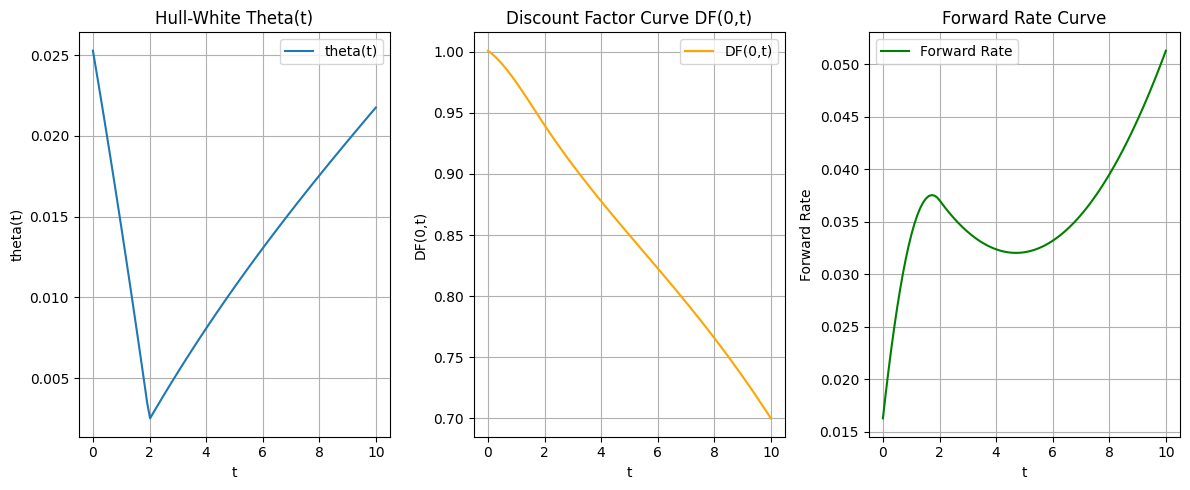

In [14]:
times = [0.5, 1.0, 2.0, 5.0, 10.0]
dfs   = [0.99, 0.975, 0.94, 0.85, 0.70]

alpha = 0.05
sigma = 0.05

hw = HullWhiteTheta(times, dfs, alpha, sigma)


times = np.linspace(0.0, 10.0, 100)
thetas = [hw.theta(t) for t in times]
dfs = [hw.df(t) for t in times]
forward_rates = [hw.fwd_rate(t) for t in times]

t = 3.0
print(hw.theta(t))

# plot theta(t) and DF(0,t) and forward rates
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(times, thetas, label="theta(t)")
plt.title("Hull-White Theta(t)")
plt.xlabel("t")
plt.ylabel("theta(t)")
plt.grid()
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(times, dfs, label="DF(0,t)", color='orange')
plt.title("Discount Factor Curve DF(0,t)")
plt.xlabel("t")
plt.ylabel("DF(0,t)")
plt.grid()
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(times, forward_rates, label="Forward Rate", color='green')
plt.title("Forward Rate Curve")
plt.xlabel("t")
plt.ylabel("Forward Rate")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

alpha_slider = widgets.FloatSlider(
    value=0.05, min=0.001, max=0.2, step=0.001,
    description="alpha", continuous_update=True
)

sigma_slider = widgets.FloatSlider(
    value=0.05, min=0.001, max=0.2, step=0.001,
    description="sigma", continuous_update=True
)


def update_plot(*args):
    try:
        times, dfs = df_table.get_data()
        times = list(times)
        dfs   = list(dfs)
        if len(times) < 2:
            return
    except:
        return

    alpha = alpha_slider.value
    sigma = sigma_slider.value

    hw = HullWhiteTheta(times, dfs, alpha, sigma)

    grid = np.linspace(0.0, max(times), 300)

    theta_vals = [hw.theta(t) for t in grid]
    df_vals    = [hw.df(t) for t in grid]
    fwd_vals   = [hw.fwd_rate(t) for t in grid]

    with fig.batch_update():
        fig.data[0].x = grid
        fig.data[0].y = theta_vals

        fig.data[1].x = grid
        fig.data[1].y = df_vals

        fig.data[2].x = grid
        fig.data[2].y = fwd_vals


class DFTable:
    def __init__(self, times, dfs):
        self.rows = []
        for t, d in zip(times, dfs):
            self.add_row(t, d)

    def add_row(self, t=100.0, d=0.1):
        time = widgets.FloatText(value=t, step=0.1, layout=widgets.Layout(width="100px"))
        df   = widgets.FloatText(value=d, step=0.001, layout=widgets.Layout(width="100px"))
        btn  = widgets.Button(description="❌", layout=widgets.Layout(width="40px"))

        row = widgets.HBox([time, df, btn])
        self.rows.append((time, df, btn, row))

        btn.on_click(lambda _: self.remove_row(row))
        time.observe(update_plot, names="value")
        df.observe(update_plot, names="value")

        self.render()
        update_plot()

    def remove_row(self, row_widget):
        self.rows = [r for r in self.rows if r[3] is not row_widget]
        self.render()
        update_plot()

    def get_data(self):
        times = [r[0].value for r in self.rows]
        dfs   = [r[1].value for r in self.rows]
        return zip(*sorted(zip(times, dfs)))

    def render(self):
        table.children = [header] + [r[3] for r in self.rows]

init_times = [0.5, 1.0, 2.0, 5.0, 10.0]
init_dfs   = [0.99, 0.975, 0.94, 0.85, 0.70]

header = widgets.HBox([
    widgets.Label("Time", layout=widgets.Layout(width="100px")),
    widgets.Label("DF",   layout=widgets.Layout(width="100px")),
    widgets.Label("",     layout=widgets.Layout(width="40px"))
])

table = widgets.VBox()
df_table = DFTable(init_times, init_dfs)

add_button = widgets.Button(description="➕ Add Node")
add_button.on_click(lambda _: df_table.add_row())

fig = go.FigureWidget(
    make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        subplot_titles=["Theta(t)", "Discount Factor DF(0,t)", "Forward Rate"]
    )
)

fig.add_trace(go.Scatter(name="theta(t)"), row=1, col=1)
fig.add_trace(go.Scatter(name="DF(0,t)"),  row=2, col=1)
fig.add_trace(go.Scatter(name="fwd_rate"), row=3, col=1)

fig.update_layout(height=700, showlegend=False)



alpha_slider.observe(update_plot, names="value")
sigma_slider.observe(update_plot, names="value")

controls = widgets.VBox([alpha_slider, sigma_slider, add_button])

display(widgets.HBox([table, controls]))
display(fig)

update_plot()


FigureWidget({
    'data': [{'name': 'theta(t)',
              'type': 'scatter',
              'uid': '0c3ece…